In [2]:
import pickle
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import rc
import numpy as np
from typing import Any, Dict, Tuple, List
from itertools import groupby
import textwrap

In [3]:
def compute_ttr(backlog: Dict[Tuple[Any, ...], float], *, zero_tol: float = 1e-9, return_open: bool = True) -> Dict[Tuple[Any, Any], List[Dict[str, Any]]]:
    if not backlog:
        return {}

    # Prepare (group, time_tuple, value) triples and sort by (group, time)
    triples = []
    for k, v in backlog.items():
        if len(k) < 3:
            raise ValueError(f"Key {k} must have at least (loc, com, time...).")
        triples.append(((k[0], k[1]), k[2:], float(v)))
    triples.sort(key=lambda x: (x[0], x[1]))  # lexicographic time handles multi-index

    results: Dict[Tuple[Any, Any], List[Dict[str, Any]]] = {}

    for g, grp in groupby(triples, key=lambda x: x[0]):
        episodes: List[Dict[str, Any]] = []
        in_run = False
        start = None
        peak = area = 0.0
        steps = 0

        for _, t, val in grp:
            if val > zero_tol:
                if not in_run:
                    in_run = True
                    start = t
                    peak = val
                    area = val
                    steps = 1
                else:
                    steps += 1
                    area += val
                    if val > peak:
                        peak = val
            elif in_run:
                episodes.append({
                    "start_idx": start,
                    "end_idx": t,                 # first nonpositive period
                    "duration_steps": steps,
                    "peak": peak,
                    "area": area,
                })
                in_run = False

        if in_run and return_open:
            episodes.append({
                "start_idx": start,
                "end_idx": None,                  # not yet recovered
                "duration_steps": steps,
                "peak": peak,
                "area": area,
            })
        
        if episodes !=[]:
            results[g] = episodes
        else:
            continue

    return results

In [4]:
def print_network_graph(ssoln_dict:dict, eps:float=0.0, norm_factor:float=1.0):
    G = nx.DiGraph()
    # ssoln_dict = iter_ssoln_dict[1]
    nodes = {
    'Location 1': {
        'Capacity': ssoln_dict['Cap_P[loc1,com1_process,0]']/norm_factor if 'Cap_P[loc1,com1_process,0]' in ssoln_dict.keys() else 0,
        'Inventory': ssoln_dict['Cap_S[loc1,com1_store_com1_in_stored,0]']/norm_factor if 'Cap_S[loc1,com1_store_com1_in_stored,0]' in ssoln_dict.keys() else 0
    },
    'Location 2': {
        'Capacity': ssoln_dict['Cap_P[loc2,com1_process,0]']/norm_factor if 'Cap_P[loc2,com1_process,0]' in ssoln_dict.keys() else 0,
        'Inventory': ssoln_dict['Cap_S[loc2,com1_store_com1_in_stored,0]']/norm_factor if 'Cap_S[loc2,com1_store_com1_in_stored,0]' in ssoln_dict.keys() else 0
    },
    'Location 3': {
        'Capacity': ssoln_dict['Cap_P[loc3,com1_process,0]']/norm_factor if 'Cap_P[loc3,com1_process,0]' in ssoln_dict.keys() else 0,
        'Inventory': ssoln_dict['Cap_S[loc3,com1_store_com1_in_stored,0]']/norm_factor if 'Cap_S[loc3,com1_store_com1_in_stored,0]' in ssoln_dict.keys() else 0
    },
    'Location 4': {
        'Capacity': ssoln_dict['Cap_P[loc4,com1_process,0]']/norm_factor if 'Cap_P[loc4,com1_process,0]' in ssoln_dict.keys() else 0,
        'Inventory': ssoln_dict['Cap_S[loc4,com1_store_com1_in_stored,0]']/norm_factor if 'Cap_S[loc4,com1_store_com1_in_stored,0]' in ssoln_dict.keys() else 0
    },
    'Location 5': {
        'Capacity': ssoln_dict['Cap_P[loc5,com1_process,0]']/norm_factor if 'Cap_P[loc5,com1_process,0]' in ssoln_dict.keys() else 0,
        'Inventory': ssoln_dict['Cap_S[loc5,com1_store_com1_in_stored,0]']/norm_factor if 'Cap_S[loc5,com1_store_com1_in_stored,0]' in ssoln_dict.keys() else 0
    },
    'Location 6': {
        'Capacity': ssoln_dict['Cap_P[loc6,com1_process,0]']/norm_factor if 'Cap_P[loc6,com1_process,0]' in ssoln_dict.keys() else 0,
        'Inventory': ssoln_dict['Cap_S[loc6,com1_store_com1_in_stored,0]']/norm_factor if 'Cap_S[loc6,com1_store_com1_in_stored,0]' in ssoln_dict.keys() else 0
    },
    'Location 7': {
        'Capacity': ssoln_dict['Cap_P[loc7,com1_process,0]']/norm_factor if 'Cap_P[loc7,com1_process,0]' in ssoln_dict.keys() else 0,
        'Inventory': ssoln_dict['Cap_S[loc7,com1_store_com1_in_stored,0]']/norm_factor if 'Cap_S[loc7,com1_store_com1_in_stored,0]' in ssoln_dict.keys() else 0
    },
    }
    
    # Add nodes to the graph
    G.add_nodes_from(nodes.keys())
    
    # Define edges (connections between nodes)
    edges = [
        ('Location 1', 'Location 2', {'weight': ssoln_dict['Cap_F[loc1,loc2,truck12,0]']/norm_factor if 'Cap_F[loc1,loc2,truck12,0]' in ssoln_dict.keys() else 0}),
        ('Location 1', 'Location 3', {'weight': ssoln_dict['Cap_F[loc1,loc3,truck13,0]']/norm_factor if 'Cap_F[loc1,loc3,truck13,0]' in ssoln_dict.keys() else 0}),
        ('Location 1', 'Location 5', {'weight': ssoln_dict['Cap_F[loc1,loc5,plane15,0]']/norm_factor if 'Cap_F[loc1,loc5,plane15,0]' in ssoln_dict.keys() else 0}),
        ('Location 2', 'Location 4', {'weight': ssoln_dict['Cap_F[loc2,loc4,truck24,0]']/norm_factor if 'Cap_F[loc2,loc4,truck24,0]' in ssoln_dict.keys() else 0}),
        ('Location 2', 'Location 5', {'weight': ssoln_dict['Cap_F[loc2,loc5,truck25,0]']/norm_factor if 'Cap_F[loc2,loc5,truck25,0]' in ssoln_dict.keys() else 0}),
        ('Location 3', 'Location 4', {'weight': ssoln_dict['Cap_F[loc3,loc4,truck34,0]']/norm_factor if 'Cap_F[loc3,loc4,truck34,0]' in ssoln_dict.keys() else 0}),
        ('Location 4', 'Location 5', {'weight': ssoln_dict['Cap_F[loc4,loc5,truck45,0]']/norm_factor if 'Cap_F[loc4,loc5,truck45,0]' in ssoln_dict.keys() else 0}),
        ('Location 4', 'Location 7', {'weight': ssoln_dict['Cap_F[loc4,loc7,truck47,0]']/norm_factor if 'Cap_F[loc4,loc7,truck47,0]' in ssoln_dict.keys() else 0}),
        ('Location 6', 'Location 4', {'weight': ssoln_dict['Cap_F[loc6,loc4,truck64,0]']/norm_factor if 'Cap_F[loc6,loc4,truck64,0]' in ssoln_dict.keys() else 0}),
        # ('Location 6', 'Location 5', {'weight': ssoln_dict['Cap_F[loc6,loc5,plane65,0]'] if 'Cap_F[loc6,loc5,plane65,0]' in ssoln_dict.keys() else 0}),
        ('Location 7', 'Location 5', {'weight': ssoln_dict['Cap_F[loc7,loc5,truck75,0]']/norm_factor if 'Cap_F[loc7,loc5,truck75,0]' in ssoln_dict.keys() else 0}),
    ]
    
    # Add edges to the graph
    G.add_edges_from(edges)
    
    # Define fixed positions for nodes
    fixed_positions = {
        'Location 1': (-2, 2),
        'Location 2': (0, 2),
        'Location 3': (-2, 0),
        'Location 4': (0, 0),
        'Location 5': (2, 0),
        'Location 6': (-2, -2),
        'Location 7': (1, -2)
    }
    
    # Create custom labels combining multiple pieces of information
    node_labels = {node: f"Capacity: {data['Capacity']:.2f}\nInventory: {data['Inventory']:.2f}" for node, data in nodes.items()}
    
    # Draw nodes and edges with fixed positions
    nx.draw_networkx_nodes(G, fixed_positions, node_color='skyblue', node_size=700)
    nx.draw_networkx_edges(G, fixed_positions, edgelist=edges, arrowstyle='simple', arrowsize=15)
    nx.draw_networkx_labels(G, fixed_positions, labels=node_labels, font_size=8, font_color='red', bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, boxstyle="round,pad=0.3"))
    
    # Draw edge labels (optional)
    edge_labels = {(u, v): round(d['weight'],3) for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, fixed_positions, edge_labels=edge_labels, label_pos=0.4, font_size=8)
    
    # Expand plot limits to prevent cutoff
    x_values, y_values = zip(*fixed_positions.values())
    plt.xlim(min(x_values) - 1, max(x_values) + 1)
    plt.ylim(min(y_values) - 1, max(y_values) + 1)
    
    # Show the plot
    plt.title(f"Supply Chain Network considering fill rate of {eps}")
    # plt.figure(figsize=(16,12))
    plt.show()  

In [5]:
# eps=1

In [6]:
# with open(f'HPRC_Results/ssoln_64_{int(eps * 10):02d}_Backlog.pkl', 'rb') as file:
#     load_ssoln = pickle.load(file)

In [7]:
# print_network_graph(ssoln_dict=load_ssoln, eps=eps, norm_factor=1)

In [8]:
eps=0.0

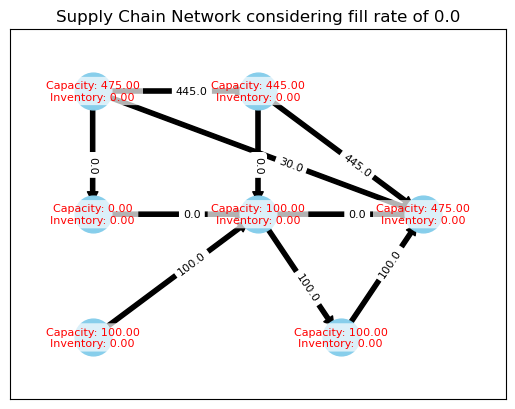

Procurement capacity at Location 1: 475.0
Procurement capacity at Location 6: 100.0


In [9]:
with open(f'ssoln_test.pkl', 'rb') as file:
        load_ssoln_test = pickle.load(file)
print_network_graph(ssoln_dict=load_ssoln_test, eps=eps, norm_factor=1)
print(f'Procurement capacity at Location 1: {load_ssoln_test["Cap_P[loc1,procure com1,0]"]}')
print(f'Procurement capacity at Location 6: {load_ssoln_test["Cap_P[loc6,procure com1,0]"]}')

In [17]:
load_ssoln_test

{'X_P[loc1,com1_loc1_send,0]': 1.0,
 'X_P[loc1,com1_loc2_send,0]': 0.0,
 'X_P[loc1,com1_loc3_send,0]': 0.0,
 'X_P[loc1,com1_loc4_send,0]': 0.0,
 'X_P[loc1,com1_loc5_send,0]': 0.0,
 'X_P[loc1,com1_loc6_send,0]': 0.0,
 'X_P[loc1,com1_loc7_send,0]': 0.0,
 'X_P[loc1,com1_process,0]': 1.0,
 'X_P[loc1,com1_receive_loc1,0]': 0.0,
 'X_P[loc1,com1_receive_loc2,0]': 0.0,
 'X_P[loc1,com1_receive_loc3,0]': 0.0,
 'X_P[loc1,com1_receive_loc4,0]': 0.0,
 'X_P[loc1,com1_receive_loc5,0]': 0.0,
 'X_P[loc1,com1_receive_loc6,0]': 0.0,
 'X_P[loc1,com1_receive_loc7,0]': 0.0,
 'X_P[loc1,com1_store,0]': 0.0,
 'X_P[loc1,com1_store_discharge,0]': 0.0,
 'X_P[loc1,procure com1,0]': 1.0,
 'X_P[loc1,sell com1,0]': 0.0,
 'X_P[loc2,com1_loc1_send,0]': 0.0,
 'X_P[loc2,com1_loc2_send,0]': 1.0,
 'X_P[loc2,com1_loc3_send,0]': 0.0,
 'X_P[loc2,com1_loc4_send,0]': 0.0,
 'X_P[loc2,com1_loc5_send,0]': 0.0,
 'X_P[loc2,com1_loc6_send,0]': 0.0,
 'X_P[loc2,com1_loc7_send,0]': 0.0,
 'X_P[loc2,com1_process,0]': 1.0,
 'X_P[loc2,com1_

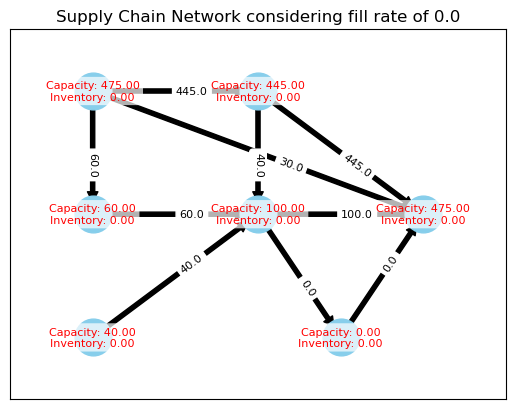

Procurement capacity at Location 1: 475.0
Procurement capacity at Location 6: 40.0


In [11]:
with open(f'ncl/ssoln_32_{int(eps * 10):02d}_ncl.pkl', 'rb') as file:
        load_ssoln_ncl = pickle.load(file)
print_network_graph(ssoln_dict=load_ssoln_ncl, eps=eps, norm_factor=1)
print(f'Procurement capacity at Location 1: {load_ssoln_ncl["Cap_P[loc1,procure com1,0]"]}')
print(f'Procurement capacity at Location 6: {load_ssoln_ncl["Cap_P[loc6,procure com1,0]"]}')

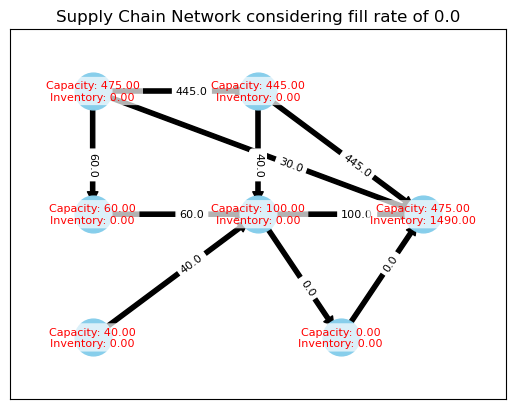

Procurement capacity at Location 1: 475.0
Procurement capacity at Location 6: 40.0


In [12]:
with open(f'cl/ssoln_128_00_cl_local.pkl', 'rb') as file:
    load_ssoln_cl = pickle.load(file)
print_network_graph(ssoln_dict=load_ssoln_cl, eps=eps, norm_factor=1)
print(f'Procurement capacity at Location 1: {load_ssoln_cl["Cap_P[loc1,procure com1,0]"]}')
print(f'Procurement capacity at Location 6: {load_ssoln_cl["Cap_P[loc6,procure com1,0]"]}')

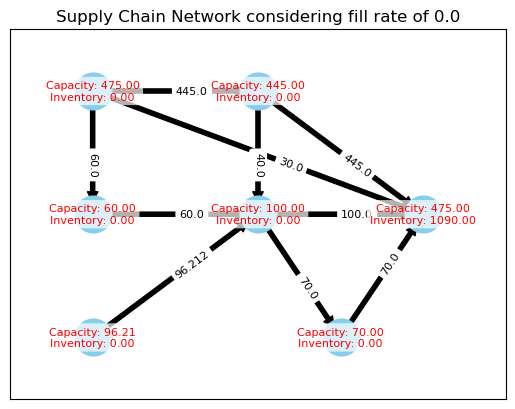

Procurement capacity at Location 1: 475.0
Procurement capacity at Location 6: 96.21212121212122


In [13]:
with open(f'cl/ssoln_128_00_cl_global.pkl', 'rb') as file:
    load_ssoln_cl = pickle.load(file)
print_network_graph(ssoln_dict=load_ssoln_cl, eps=eps, norm_factor=1)
print(f'Procurement capacity at Location 1: {load_ssoln_cl["Cap_P[loc1,procure com1,0]"]}')
print(f'Procurement capacity at Location 6: {load_ssoln_cl["Cap_P[loc6,procure com1,0]"]}')

In [14]:
# with open(f'cl/ssoln_128_{int(eps * 10):02d}_Backlog_cl_new.pkl', 'rb') as file:
#         load_ssoln_cl = pickle.load(file)
# print_network_graph(ssoln_dict=load_ssoln_cl, eps=eps, norm_factor=1)
# print(f'Procurement capacity at Location 1: {load_ssoln_cl["Cap_P[loc1,procure com1,0]"]}')
# print(f'Procurement capacity at Location 6: {load_ssoln_cl["Cap_P[loc6,procure com1,0]"]}')

In [15]:
# with open(f'cl_step2/ssoln_256_{int(eps * 10):02d}_Backlog_cl_step2.pkl', 'rb') as file:
#         load_ssoln_cl_step2 = pickle.load(file)
# print_network_graph(ssoln_dict=load_ssoln_cl_step2, eps=eps, norm_factor=1)
# print(f'Procurement capacity at Location 1: {load_ssoln_cl_step2["Cap_P[loc1,procure com1,0]"]}')
# print(f'Procurement capacity at Location 6: {load_ssoln_cl_step2["Cap_P[loc6,procure com1,0]"]}')

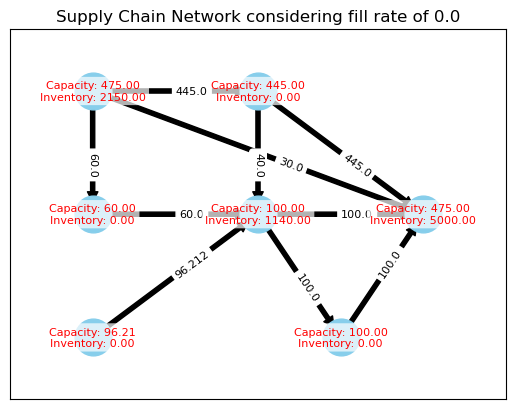

Procurement capacity at Location 1: 475.0
Procurement capacity at Location 6: 96.21212121212011


In [18]:
with open(f'cl2/ssoln_256_00_cl2_global.pkl', 'rb') as file:
        load_ssoln_cl_step2_new = pickle.load(file)
print_network_graph(ssoln_dict=load_ssoln_cl_step2_new, eps=eps, norm_factor=1)
print(f'Procurement capacity at Location 1: {load_ssoln_cl_step2_new["Cap_P[loc1,procure com1,0]"]}')
print(f'Procurement capacity at Location 6: {load_ssoln_cl_step2_new["Cap_P[loc6,procure com1,0]"]}')

In [22]:
load_ssoln_cl_step2_new['Cap_P[loc5,com1_receive_loc7,0]']

100.0

In [ ]:
load_ssoln_cl_step2_new['Cap_S[loc5,com1_store_com1_in_stored,0]']

In [ ]:
load_ssoln_cl['Cap_S[loc5,com1_store_com1_in_stored,0]']

In [ ]:
with open (f'cl_step3/ssoln_256_{int(eps * 10):02d}_Backlog_cl_step3.pkl', 'rb') as file:
        load_ssoln_cl_step3 = pickle.load(file)
print_network_graph(ssoln_dict=load_ssoln_cl_step3, eps=eps, norm_factor=1)
print(f'Procurement capacity at Location 1: {load_ssoln_cl_step3["Cap_P[loc1,procure com1,0]"]}')
print(f'Procurement capacity at Location 6: {load_ssoln_cl_step3["Cap_P[loc6,procure com1,0]"]}')

In [ ]:
with open(f'ncl/results_32_{int(eps * 10):02d}_Backlog_ncl.pkl', 'rb') as file:
    results_ncl = pickle.load(file)

In [ ]:
results_ncl

In [ ]:
with open(f'cl/results_128_{int(eps * 10):02d}_Backlog_cl.pkl', 'rb') as file:
    results_cl = pickle.load(file)

In [ ]:
results_cl

In [ ]:
(results_cl['First Stage Cost'] - results_ncl['First Stage Cost'])/results_ncl['First Stage Cost']

In [ ]:
with open(f'cl_step2/results_256_{int(eps * 10):02d}_Backlog_cl_step2_new.pkl', 'rb') as file:
    results_cl_step2_new = pickle.load(file)

In [ ]:
results_cl_step2_new

In [ ]:
(results_cl_step2_new['First Stage Cost'] - results_cl['First Stage Cost'])/results_cl['First Stage Cost']

In [ ]:
with open(f'ncl/output_32_00_Backlog_ncl.pkl', 'rb') as file:
    load_output_ncl = pickle.load(file)

In [ ]:
with open(f'cl/output_128_00_Backlog_cl.pkl', 'rb') as file:
    load_output_cl = pickle.load(file)

In [ ]:
load_output_ncl.keys()

In [ ]:
ncl_ttr_dict = {}

In [ ]:
for scen in load_output_ncl:
    ncl_ttr_dict[scen] = compute_ttr(backlog=load_output_ncl[scen]['Demand_backlog'])

In [ ]:
for scen in ncl_ttr_dict:
    if len(ncl_ttr_dict[scen][('loc5', 'com1_sold')]) >1:
        for e in ncl_ttr_dict[scen][('loc5', 'com1_sold')]:
            print(f'{scen}, {e["duration_steps"]}')

In [ ]:
cl_ttr_dict = {}

In [ ]:
for scen in load_output_cl:
    cl_ttr_dict[scen] = compute_ttr(backlog=load_output_cl[scen]['Demand_backlog'])

In [ ]:
l = ['cap7_nd cap2_1 truck25_nd res6_nd', 'cap7_nd cap2_2 truck25_nd res6_nd', 'cap7_nd cap2_3 truck25_nd res6_nd', 'cap7_nd cap2_nd truck25_nd res6_nd']

In [ ]:
for scen in cl_ttr_dict:
    if len(cl_ttr_dict[scen][('loc5', 'com1_sold')]) >1:
        for e in cl_ttr_dict[scen][('loc5', 'com1_sold')]:
            print(f'{scen}, {e["start_idx"]}, {e["end_idx"]}, {e["duration_steps"]}')

In [ ]:
# with open(f'cl_step2/output_256_00_Backlog_cl_step2.pkl', 'rb') as file:
#     load_output_cl_step2 = pickle.load(file)

In [ ]:
# with open(f'cl_step3/output_256_00_Backlog_cl_step3.pkl', 'rb') as file:
#     load_output_cl_step3 = pickle.load(file)

In [ ]:
load_output_ncl[list(load_output_ncl.keys())[0]]['Capex_network']

In [ ]:
load_output_ncl[list(load_output_ncl.keys())[0]]['Capex_storage']

In [ ]:
ncl_capex_storage = sum(v for k,v in load_output_ncl[list(load_output_ncl.keys())[0]]['Capex_storage'].items())
cl_capex_storage = sum(v for k,v in load_output_cl[list(load_output_cl.keys())[0]]['Capex_storage'].items())
# cl_step2_capex_storage = sum(v for k,v in load_output_cl_step2[list(load_output_cl_step2.keys())[0]]['Capex_storage'].items())
# cl_step3_capex_storage = sum(v for k,v in load_output_cl_step3[list(load_output_cl_step3.keys())[0]]['Capex_storage'].items())

ncl_capex_process = sum(v for k,v in load_output_ncl[list(load_output_ncl.keys())[0]]['Capex_network'].items()) - ncl_capex_storage
cl_capex_process = sum(v for k,v in load_output_cl[list(load_output_cl.keys())[0]]['Capex_network'].items()) - cl_capex_storage
# cl_step2_capex_process = sum(v for k,v in load_output_cl_step2[list(load_output_cl_step2.keys())[0]]['Capex_network'].items()) - cl_step2_capex_storage
# cl_step3_capex_process = sum(v for k,v in load_output_cl_step3[list(load_output_cl_step3.keys())[0]]['Capex_network'].items()) - cl_step3_capex_storage

ncl_capex_transport = sum(v for k,v in load_output_ncl[list(load_output_ncl.keys())[0]]['Capex_transport_network'].items())
cl_capex_transport = sum(v for k,v in load_output_cl[list(load_output_cl.keys())[0]]['Capex_transport_network'].items())

data = [
    [ncl_capex_process, cl_capex_process], # Process Capex
    [ncl_capex_storage, cl_capex_storage], # Storage Capex
    [ncl_capex_transport, cl_capex_transport]  # Transport Capex
]

# data = [
#     [ncl_capex_process, cl_capex_process, cl_step2_capex_process, cl_step3_capex_process], # Process Capex
#     [ncl_capex_storage, cl_capex_storage, cl_step2_capex_storage, cl_step3_capex_storage], # Storage Capex
#     [ncl_capex_transport, cl_capex_transport, cl_step2_capex_transport, cl_step3_capex_transport]  # Transport Capex
# ]

# Transpose the data for plotting
data_transposed = np.array(data)

# Create stacked bar plot
rc('font', **{'family': 'serif',
           'serif': ['Computer Modern'], 'size': 16})
fig, ax = plt.subplots(figsize = (9,6))
labels = ['Capex_Process', 'Capex_Storage', 'Capex_Transport']
for i in range(len(data)):
    bar = ax.bar(np.arange(len(data[i])), data_transposed[i], bottom = np.sum(data_transposed[:i], axis=0), label = labels[i])

# Add labels, title, and legend
ax.set_xlabel('Scenario')
ax.set_ylabel('Total cost (USD)')
ax.set_title('Capital Expenditure Breakdown')

xtick_positions = np.arange(len(data[0]))
xtick_labels = ['ncl', 'cl']
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3)
plt.grid(zorder=0, alpha = 0.3)
plt.rcdefaults()

plt.savefig(fname = 'Capex Cost Breakdown', dpi = 300)
# Show the plot
plt.show()

In [ ]:
# for eps in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
#     with open(f'ssoln_32_{int(eps * 10):02d}_Backlog_ncl.pkl', 'rb') as file:
#         load_ssoln = pickle.load(file)
#     print_network_graph(ssoln_dict=load_ssoln, eps=eps, norm_factor=1)
#     print(f'Procurement capacity at Location 1: {load_ssoln["Cap_P[loc1,procure com1,0]"]}')
#     print(f'Procurement capacity at Location 6: {load_ssoln["Cap_P[loc6,procure com1,0]"]}')

In [ ]:
# rc('font', **{'family': 'serif', 'size': 14})
# 
# fig, ax = plt.subplots(figsize = (8, 6))
# # ax1 = ax.twinx()
# 
# x, y = list(), list()
# for eps in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
#     x.append(eps)
#     with open(f'HPRC_results/results_64_{int(eps * 10):02d}_Backlog.pkl', 'rb') as file:
#         load_results = pickle.load(file)
#     y.append(load_results['Expected Cost UI'])
# # Example data
# # x = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
# # y = [414840.2028, 414840.2028, 425383.94, 435927.6931, 446471.4384, 457015.1836]
# y2 = [25594, 25594, 29495, 3396, 37297, 41198]
# # Plotting
# ax.plot(x, y, marker='o', label='ef_obj', color = 'green', linewidth=3, markersize=10)  # 'o' adds circular markers at data points
# # ax1.plot(x, y2, marker='x', label='approx_obj', color ='blue')
# plt.title('Expected Cost - Extensive Form')
# ax.set_ylabel('Expected Cost')
# # ax1.set_ylabel('Expected Cost (Approx.)')
# ax.set_xlabel('Fill rate')
# plt.grid(alpha = 0.3)
# # ax1.legend(loc='lower right')
# ax.legend(loc='upper left')
# plt.tight_layout()
# plt.savefig(fname = 'pareto_ef', dpi = 300)
# plt.show()
# plt.rcdefaults()